# CHIME: SF empírica vs instrumental

Este notebook compara a selection function empírica do CHIME, construída a partir do catálogo observado, com uma selection function instrumental do CHIME construída a partir de mapas instrumentais.

O fluxo é:

1. carregar catálogo e construir SFs empíricas;
2. extrair a SF empírica do CHIME;
3. construir a SF instrumental do CHIME;
4. comparar mapas, diferença, razão e métricas de entropia/divergência;
5. opcionalmente rodar mocks empírico vs instrumental.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy')

In [2]:
from frb_isotropy.core.config import AnalysisConfig, create_runtime_context
from frb_isotropy.catalog.catalog import load_catalog, apply_mask
from frb_isotropy.selection import (
    build_survey_selection_functions,
    extract_chime_empirical_sf,
    build_masked_chime_instrumental_sf,
    compare_chime_selection_maps,
    plot_chime_selection_comparison,
    plot_ratio_histogram,
    plot_empirical_vs_instrumental_scatter,
    build_chime_instrumental_selection_set,
    build_chime_only_selection_set,
    run_chime_mock_comparison,
)
from frb_isotropy.selection.instrumental import ChimeInstrumentalComponents

## Configuração

Esta configuração reproduz o modo com máscara galáctica e selection functions. Os parâmetros de mocks abaixo são propositalmente leves para testes interativos.

In [3]:
config = AnalysisConfig(
    name="CHIME_SFComparison",
    project_root=PROJECT_ROOT,
    outputs_root=PROJECT_ROOT / "outputs" / "chime_sf_comparison",
    catalog_path=PROJECT_ROOT / "data" / "SkyPosition.csv",
    use_gal_mask=True,
    use_sel_func=True,
    n_jobs=4,
    gal_cut=20.0,
    min_sep=0.0,
    max_sep=180.0,
    bin_size=10.0,
    coarse_bins=(0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0),
    nside_sf=32,
    smooth_sigma=3.0,
    perturbation_scale=1.0,
    n_rand_factor=20,
    n_ensemble=2,
    n_mocks_per_ensemble=5,
    random_seed=12345,
    mock_seed_base=100000,
    random_catalog_seed_base=200000,
    sf_perturbation_seed_base=300000,
    jackknife_seed_base=400000,
    bootstrap_seed_base=500000,
    selection_function_floor=1e-12,
    numerical_eigenvalue_floor=1e-15,
    stable_eigenvalue_floor=1e-12,
    numerical_zero_tolerance=1e-30,
    svd_eigenvalue_cut=0.01,
    nside_jackknife=4,
    min_jackknife_regions=20,
    n_bootstrap=100,
    overlap_radius_deg=5.0,
    overlap_nside=32,
    run_top_survey_maps=False,
)

context = create_runtime_context(config)
context.outputs.figures_dir.mkdir(parents=True, exist_ok=True)
context.outputs.tables_dir.mkdir(parents=True, exist_ok=True)

context.outputs.run_dir

PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/CHIME_SFComparison_mask_sf_gal20_bin10_nside32_smooth3')

## SF empírica do CHIME

In [4]:
df_data = load_catalog(context)
df_data = apply_mask(context, df_data)

selection_functions = build_survey_selection_functions(
    context=context,
    df_data=df_data,
    nside=config.nside_sf,
    smooth_sigma=config.smooth_sigma,
    gal_cut=config.gal_cut,
)

sf_emp = extract_chime_empirical_sf(selection_functions)

print(f"N observed after mask: {len(df_data)}")
print(f"nside: {selection_functions.nside}")
print(f"CHIME empirical SF sum: {sf_emp.sum():.12f}")
print(f"CHIME survey weight: {selection_functions.survey_weights['CHIME']:.6f}")


--- Catalog loaded ---
Objects: 4066

--- Galactic mask applied ---
gal_cut = ±20.0 deg
Remaining objects: 2518
Removed objects: 1548

--- Survey partitioning ---
Unique surveys: 19

Survey populations:
          CHIME | N=2341 |  92.97%
         FRBCAT | N=  77 |   3.06%
          CRAFT | N=  33 |   1.31%
         PARKES | N=  22 |   0.87%
          ALERT | N=  15 |   0.60%
       MeerTRAP | N=   8 |   0.32%
           FAST | N=   5 |   0.20%
     Pan-STARRS | N=   4 |   0.16%
          ATLAS | N=   3 |   0.12%
   VLA-realfast | N=   2 |   0.08%
     GaiaAlerts | N=   2 |   0.08%
         UTMOST | N=   2 |   0.08%
            ZTF | N=   1 |   0.04%
        Tianlai | N=   1 |   0.04%
         TRAPUM | N=   1 |   0.04%
     VLITE-Fast | N=   1 |   0.04%
          GBNCC | N=   1 |   0.04%
         MASTER | N=   1 |   0.04%
        ASAS-SN | N=   1 |   0.04%

--- Building selection functions ---
Unique surveys: 19
Adaptive smoothing: False
            ZTF | N=   1 | sigma= 3.0 deg | weig

## SF instrumental do CHIME

In [5]:
# ==============================================================================
# CHIME instrumental model
# ==============================================================================

EXPOSURE_MAP_PATH = None
BEAM_MAP_PATH = None
DAILY_SENSITIVITY_MAP_PATH = None
SPECTRAL_RESPONSE_MAP_PATH = None


def load_optional_map(
    path,
):
    """
    Load an externally supplied HEALPix map.

    Parameters
    ----------
    path : str | Path | None

    Returns
    -------
    ndarray | None
    """

    if path is None:

        return None

    return np.asarray(
        np.load(path),
        dtype=float,
    )


def analytic_chime_declination_exposure(
    nside: int,
    *,
    latitude_deg: float = 49.3207,
    dec_min_deg: float = -10.0,
    dec_max_deg: float = 90.0,
    pole_cap_deg: float = 89.0,
    normalize_peak: bool = True,
):
    """
    Approximate CHIME exposure model.

    The model is based on the fact that CHIME is a
    transit telescope. Sources remain inside the
    E-W beam for a duration that increases with
    declination.

    To first order,

        exposure(dec) ∝ transit_duration(dec)

    and

        transit_duration(dec) ∝ sec(dec)

    until saturation near the celestial pole.

    Parameters
    ----------
    nside
        HEALPix resolution.

    latitude_deg
        Geographic latitude of CHIME.

    dec_min_deg
        Southern declination limit.

    dec_max_deg
        Northern declination limit.

    pole_cap_deg
        Numerical cap used to avoid divergence
        of sec(dec) near +90 deg.

    normalize_peak
        Rescale map so that max(exposure)=1.

    Returns
    -------
    ndarray
        Relative exposure map.
    """

    npix = hp.nside2npix(
        nside
    )

    theta, _ = hp.pix2ang(
        nside,
        np.arange(npix),
    )

    dec = (
        90.0
        - np.degrees(theta)
    )

    exposure = np.zeros(
        npix,
        dtype=float,
    )

    # --------------------------------------------------
    # Sky accessible to CHIME
    # --------------------------------------------------

    visible = (
        (dec >= dec_min_deg)
        &
        (dec <= dec_max_deg)
    )

    # --------------------------------------------------
    # Transit-duration model
    # --------------------------------------------------

    dec_safe = np.clip(
        dec,
        -pole_cap_deg,
        pole_cap_deg,
    )

    exposure[visible] = (
        1.0
        /
        np.cos(
            np.radians(
                dec_safe[visible]
            )
        )
    )

    # --------------------------------------------------
    # Normalize peak response
    # --------------------------------------------------

    if (
        normalize_peak
        and np.max(exposure) > 0
    ):
        exposure /= np.max(
            exposure
        )

    return exposure.astype(
        float
    )


# ==============================================================================
# Exposure model
# ==============================================================================

exposure = load_optional_map(
    EXPOSURE_MAP_PATH
)

if exposure is None:

    exposure = (
        analytic_chime_declination_exposure(
            selection_functions.nside,
        )
    )


# ==============================================================================
# Instrumental components
# ==============================================================================

components = (
    ChimeInstrumentalComponents(
        exposure=exposure,

        beam=load_optional_map(
            BEAM_MAP_PATH
        ),

        daily_sensitivity=load_optional_map(
            DAILY_SENSITIVITY_MAP_PATH
        ),

        spectral_response=load_optional_map(
            SPECTRAL_RESPONSE_MAP_PATH
        ),
    )
)


# ==============================================================================
# Final instrumental selection function
# ==============================================================================

sf_inst = (
    build_masked_chime_instrumental_sf(
        context=context,
        components=components,
        nside=selection_functions.nside,
        gal_cut=config.gal_cut,
        use_gal_mask=config.use_gal_mask,
    )
)

print(
    f"CHIME instrumental SF sum: "
    f"{sf_inst.sum():.12f}"
)

print(
    f"Instrumental active pixels: "
    f"{np.sum(sf_inst > 0)} / {len(sf_inst)}"
)

CHIME instrumental SF sum: 1.000000000000
Instrumental active pixels: 4850 / 12288


## Comparação dos mapas

In [6]:
comparison = compare_chime_selection_maps(
    sf_empirical=sf_emp,
    sf_instrumental=sf_inst,
)

comparison.metrics
comparison.metrics.T

,0,1,2
label,empirical,instrumental,comparison
sum,1.0,1.0,0.0
min,0.0,0.0,-0.002248
max,0.003314,0.005451,0.000726
nonzero_pixels,6861.0,4850.0,6861.0
nonzero_fraction,0.55835,0.394694,0.55835
entropy_bits,11.558258,11.882912,NaN
effective_pixels,3015.659177,3776.70405,NaN
effective_sky_fraction,0.245415,0.307349,NaN
l1_distance,NaN,NaN,0.401895


In [7]:
comparison_row = (
    comparison.metrics
    .query("label == 'comparison'")
    .iloc[0]
)

comparison_row[
    [
        "correlation",
        "mean_ratio",
        "median_ratio",
        "std_ratio",
        "jensen_shannon",
    ]
]

correlation       0.883149
mean_ratio        0.909286
median_ratio      0.901985
std_ratio         0.571448
jensen_shannon    0.042274
Name: 2, dtype: object

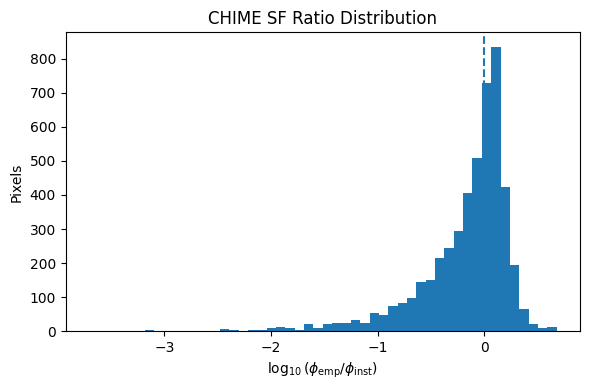

In [8]:
plot_ratio_histogram(
    comparison,
)

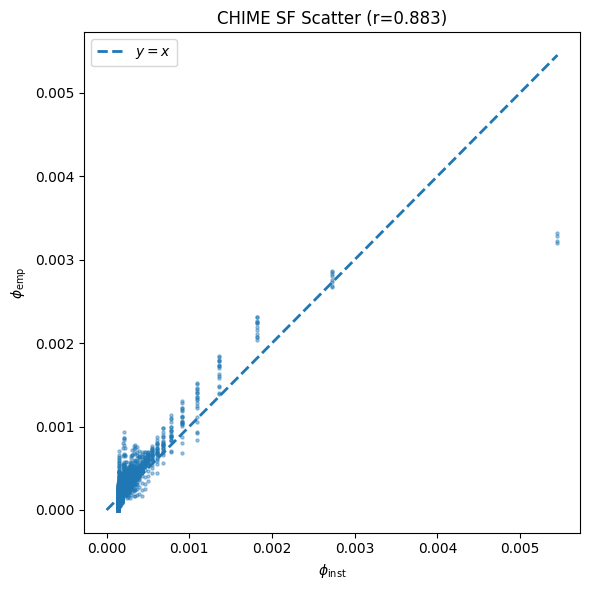

In [9]:
plot_empirical_vs_instrumental_scatter(
    comparison,
)

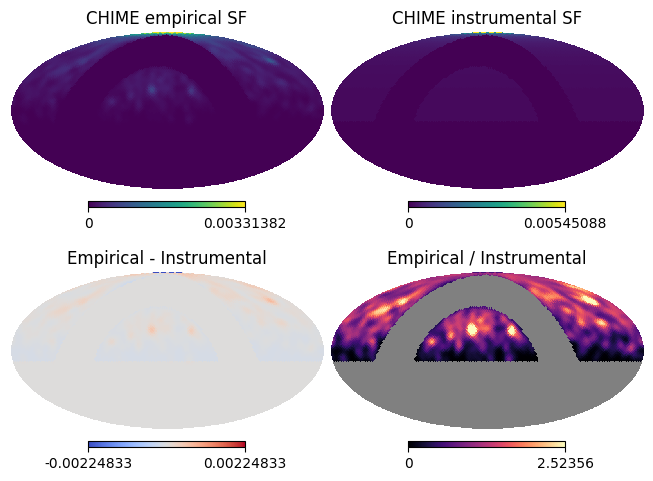

PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/CHIME_SFComparison_mask_sf_gal20_bin10_nside32_smooth3/figures/chime_empirical_vs_instrumental_sf.png')

In [10]:
figure_path = context.outputs.figures_dir / "chime_empirical_vs_instrumental_sf.png"

plot_chime_selection_comparison(
    comparison,
    save_path=figure_path,
)

plt.show()
figure_path

In [11]:
metrics_path = context.outputs.tables_dir / "chime_empirical_vs_instrumental_sf_metrics.csv"
comparison.metrics.to_csv(metrics_path, index=False)
metrics_path

PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/CHIME_SFComparison_mask_sf_gal20_bin10_nside32_smooth3/tables/chime_empirical_vs_instrumental_sf_metrics.csv')

## SelectionFunctionSet alternativos

`sf_set_inst_full` mantém todos os surveys e substitui apenas o mapa do CHIME. Essa é a opção recomendada para medir o impacto no pipeline completo.

`sf_set_emp_chime_only` e `sf_set_inst_chime_only` isolam apenas o CHIME.

In [12]:
sf_set_emp_full = selection_functions

sf_set_inst_full = build_chime_instrumental_selection_set(
    empirical_sf_set=selection_functions,
    sf_instrumental=sf_inst,
    covariance_mode="zero",
)

sf_set_emp_chime_only = build_chime_only_selection_set(
    sf_emp,
    covariance=selection_functions.sf_cov_diag_dict["CHIME"],
)

sf_set_inst_chime_only = build_chime_only_selection_set(sf_inst)

print("Full empirical surveys:", sf_set_emp_full.n_surveys)
print("Full instrumental surveys:", sf_set_inst_full.n_surveys)
print("CHIME-only empirical surveys:", sf_set_emp_chime_only.n_surveys)
print("CHIME-only instrumental surveys:", sf_set_inst_chime_only.n_surveys)

Full empirical surveys: 19
Full instrumental surveys: 19
CHIME-only empirical surveys: 1
CHIME-only instrumental surveys: 1


## Mocks empírico vs instrumental

Por segurança, esta célula não roda automaticamente. Para testar rapidamente, deixe `RUN_MOCKS = True` e mantenha `N_ENSEMBLE_COMPARISON` e `N_MOCKS_PER_COMPARISON` pequenos. Para produção, aumente esses números.

In [13]:
RUN_MOCKS = True
MOCK_MODE = "full"  # "full" or "chime_only"
N_ENSEMBLE_COMPARISON = 20
N_MOCKS_PER_COMPARISON = 50

mock_comparison = None

if RUN_MOCKS:
    if MOCK_MODE == "full":
        empirical_mock_sf_set = sf_set_emp_full
        instrumental_mock_sf_set = sf_set_inst_full
    elif MOCK_MODE == "chime_only":
        empirical_mock_sf_set = sf_set_emp_chime_only
        instrumental_mock_sf_set = sf_set_inst_chime_only
    else:
        raise ValueError("MOCK_MODE must be 'full' or 'chime_only'.")

    mock_comparison = run_chime_mock_comparison(
        context=context,
        df_data=df_data,
        empirical_sf_set=empirical_mock_sf_set,
        instrumental_sf_set=instrumental_mock_sf_set,
        n_ensemble=N_ENSEMBLE_COMPARISON,
        n_mocks_per=N_MOCKS_PER_COMPARISON,
        perturbation_scale=0.0,
        n_rand_factor=config.n_rand_factor,
        n_jobs=config.n_jobs,
    )

    print(mock_comparison.metadata)
else:
    print("Mocks skipped. Set RUN_MOCKS = True to run this block.")


--- Generating H0 ensemble mocks (with selection functions) ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/brunowesley/projetos/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Generated mocks:
  w(theta): (1000, 18)
  |<w>| tomography: (1000, 9)

--- Generating H0 ensemble mocks (with selection functions) ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generated mocks:
  w(theta): (1000, 18)
  |<w>| tomography: (1000, 9)
{'n_empirical_mocks': 1000, 'n_instrumental_mocks': 1000, 'perturbation_scale': 0.0, 'comparison': 'CHIME empirical vs instrumental SF'}


,theta_deg,empirical_mean,empirical_std,instrumental_mean,instrumental_std,delta,sigma_combined,zscore
0,5.0,-0.000791,0.003084,-0.000727,0.003395,-0.000064,0.004587,-0.014049
1,15.0,-0.000210,0.002125,-0.000293,0.002288,0.000084,0.003123,0.026800
2,25.0,-0.000436,0.001834,-0.000494,0.002104,0.000058,0.002791,0.020802
3,35.0,-0.000371,0.001688,-0.000388,0.002070,0.000018,0.002671,0.006562
4,45.0,-0.000359,0.001770,-0.000482,0.001976,0.000124,0.002653,0.046550
5,55.0,-0.000391,0.001901,-0.000384,0.001905,-0.000007,0.002691,-0.002592
6,65.0,-0.000489,0.001826,-0.000353,0.001831,-0.000137,0.002586,-0.052786
7,75.0,-0.000421,0.001925,-0.000447,0.001853,0.000027,0.002672,0.009960
8,85.0,-0.000270,0.002055,-0.000412,0.001847,0.000143,0.002763,0.051702
9,95.0,-0.000540,0.002324,-0.000434,0.001886,-0.000105,0.002993,-0.035158


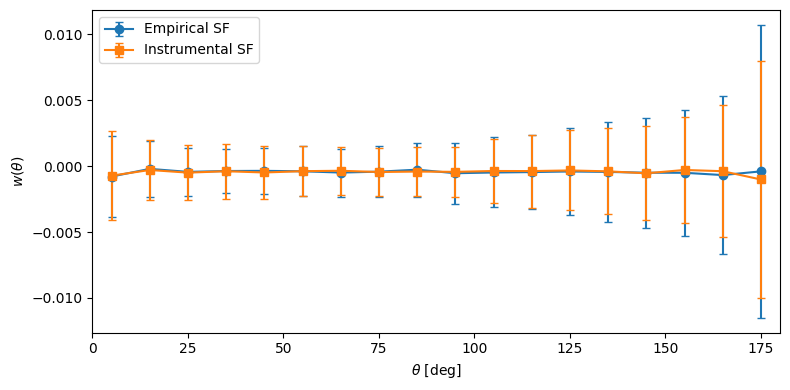

,theta_deg,delta,sigma_combined,zscore
0,5.0,-0.000064,0.004587,-0.014049
1,15.0,0.000084,0.003123,0.026800
2,25.0,0.000058,0.002791,0.020802
3,35.0,0.000018,0.002671,0.006562
4,45.0,0.000124,0.002653,0.046550
5,55.0,-0.000007,0.002691,-0.002592
6,65.0,-0.000137,0.002586,-0.052786
7,75.0,0.000027,0.002672,0.009960
8,85.0,0.000143,0.002763,0.051702
9,95.0,-0.000105,0.002993,-0.035158


In [14]:
if mock_comparison is not None:

    emp_w = np.asarray(
        mock_comparison.empirical.w_theta,
        dtype=float,
    )

    inst_w = np.asarray(
        mock_comparison.instrumental.w_theta,
        dtype=float,
    )

    theta_centers = (
        np.arange(
            emp_w.shape[1]
        )
        * config.bin_size
        + config.bin_size / 2
    )

    emp_mean = emp_w.mean(
        axis=0
    )

    inst_mean = inst_w.mean(
        axis=0
    )

    emp_std = emp_w.std(
        axis=0,
        ddof=1,
    )

    inst_std = inst_w.std(
        axis=0,
        ddof=1,
    )

    sigma_combined = np.sqrt(
        emp_std**2
        +
        inst_std**2
    )

    zscore = np.full_like(
        emp_mean,
        np.nan,
    )

    valid = (
        sigma_combined > 0.0
    )

    zscore[valid] = (
        (emp_mean[valid]
         - inst_mean[valid])
        /
        sigma_combined[valid]
    )

    wtheta_summary = pd.DataFrame(
        {
            "theta_deg":
                theta_centers,

            "empirical_mean":
                emp_mean,

            "empirical_std":
                emp_std,

            "instrumental_mean":
                inst_mean,

            "instrumental_std":
                inst_std,

            "delta":
                emp_mean
                - inst_mean,

            "sigma_combined":
                sigma_combined,

            "zscore":
                zscore,
        }
    )

    display(
        wtheta_summary
    )

    plt.figure(
        figsize=(8, 4)
    )

    plt.errorbar(
        theta_centers,
        emp_mean,
        yerr=emp_std,
        marker="o",
        capsize=3,
        label="Empirical SF",
    )

    plt.errorbar(
        theta_centers,
        inst_mean,
        yerr=inst_std,
        marker="s",
        capsize=3,
        label="Instrumental SF",
    )

    plt.xlabel(
        r"$\theta$ [deg]"
    )

    plt.ylabel(
        r"$w(\theta)$"
    )

    plt.xlim(
        0,
        180,
    )

    plt.xticks(
        [0, 25, 50, 75, 100, 125, 150, 175]
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

    display(
        wtheta_summary[
            [
                "theta_deg",
                "delta",
                "sigma_combined",
                "zscore",
            ]
        ]
    )

,theta_deg,empirical_mean_abs,empirical_std_abs,instrumental_mean_abs,instrumental_std_abs,delta_mean_abs,relative_delta
0,10.0,0.004183,0.002344,0.004647,0.002460,-0.000464,-0.110960
1,30.0,0.002832,0.001641,0.003333,0.001866,-0.000501,-0.176972
2,50.0,0.002922,0.001736,0.003124,0.001762,-0.000202,-0.069274
3,70.0,0.002990,0.001789,0.002988,0.001640,0.000002,0.000551
4,90.0,0.003511,0.001987,0.003047,0.001710,0.000464,0.132180
5,110.0,0.004360,0.002574,0.004121,0.002242,0.000239,0.054811
6,130.0,0.005669,0.003189,0.005017,0.002834,0.000651,0.114917
7,150.0,0.007185,0.003882,0.006019,0.003405,0.001166,0.162247
8,170.0,0.013651,0.007772,0.011219,0.006226,0.002431,0.178109


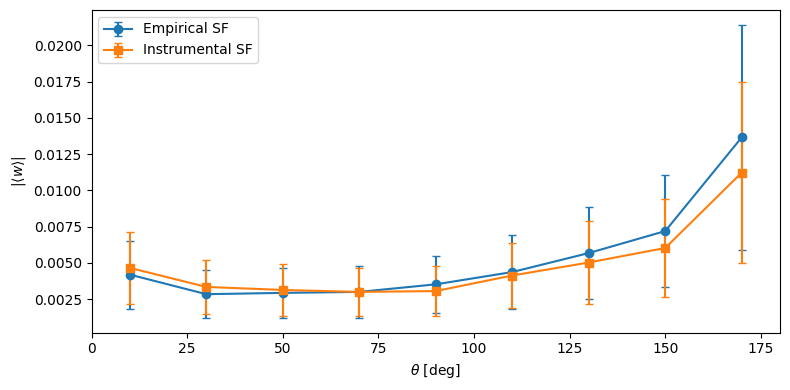

In [15]:
if mock_comparison is not None:

    emp_abs = np.asarray(
        mock_comparison.empirical.abs_statistics,
        dtype=float,
    )

    inst_abs = np.asarray(
        mock_comparison.instrumental.abs_statistics,
        dtype=float,
    )

    coarse_bins = np.asarray(
        config.coarse_bins,
        dtype=float,
    )

    coarse_centers = (
        coarse_bins[:-1]
        + coarse_bins[1:]
    ) / 2.0

    emp_mean = emp_abs.mean(
        axis=0
    )

    inst_mean = inst_abs.mean(
        axis=0
    )

    emp_std = emp_abs.std(
        axis=0,
        ddof=1,
    )

    inst_std = inst_abs.std(
        axis=0,
        ddof=1,
    )

    mock_summary = pd.DataFrame(
        {
            "theta_deg":
                coarse_centers,

            "empirical_mean_abs":
                emp_mean,

            "empirical_std_abs":
                emp_std,

            "instrumental_mean_abs":
                inst_mean,

            "instrumental_std_abs":
                inst_std,

            "delta_mean_abs":
                emp_mean - inst_mean,

            "relative_delta":
                (
                    emp_mean
                    - inst_mean
                )
                / emp_mean,
        }
    )

    display(
        mock_summary
    )

    mock_summary_path = (
        context.outputs.tables_dir
        / "chime_empirical_vs_instrumental_mock_summary.csv"
    )

    mock_summary.to_csv(
        mock_summary_path,
        index=False,
    )

    plt.figure(
        figsize=(8, 4)
    )

    plt.errorbar(
        coarse_centers,
        emp_mean,
        yerr=emp_std,
        marker="o",
        capsize=3,
        label="Empirical SF",
    )

    plt.errorbar(
        coarse_centers,
        inst_mean,
        yerr=inst_std,
        marker="s",
        capsize=3,
        label="Instrumental SF",
    )

    plt.xlabel(
        r"$\theta$ [deg]"
    )

    plt.ylabel(
        r"$|\langle w \rangle|$"
    )

    plt.xlim(
        0,
        180,
    )

    plt.xticks(
        [0, 25, 50, 75, 100, 125, 150, 175]
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

    mock_summary_path